In [1]:
# ─────────────────────────────────────────────────────────────────
#  Student Performance Predictor — Exploratory Data Analysis
#  Author  : Aryansingh Bais
#  Dataset : 1000 students | 9 features + 1 target (final_score)
# ─────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global Style ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"      : 120,
    "axes.titlesize"  : 13,
    "axes.titleweight": "bold",
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/student_data.csv')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Memory Usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"  Duplicate Rows: {df.duplicated().sum()}")
print("=" * 55)

df.head(10)

  DATASET OVERVIEW
  Shape         : 1000 rows × 10 columns
  Memory Usage  : 189.2 KB
  Duplicate Rows: 0


,study_hours_per_day,attendance_percentage,previous_score,sleep_hours_per_day,extracurricular_activities,parent_education_level,internet_access,tutoring_sessions_per_week,motivation_level,final_score
0,4.4,59.3,47.0,8.0,1,Graduate,0,2,Medium,44.1
1,9.6,77.1,46.1,8.8,0,High School,1,2,High,69.9
2,7.6,93.6,88.9,5.5,1,Graduate,0,5,Medium,83.3
3,6.4,86.6,46.2,7.7,0,No Formal Education,1,3,Low,57.7
4,2.4,90.3,47.7,7.4,0,Graduate,0,2,High,51.7
5,2.4,82.9,79.4,9.0,0,Graduate,1,4,Medium,63.9
6,1.5,84.6,59.2,9.4,1,Graduate,1,2,High,60.1
7,8.8,92.5,80.5,4.1,0,Graduate,0,4,Medium,77.8
8,6.4,62.5,34.2,8.0,1,Post-Graduate,1,2,Medium,54.1
9,7.4,74.5,61.7,4.3,0,High School,0,4,High,62.3


In [3]:
print("── Column Info ──────────────────────────────────────")
info = pd.DataFrame({
    'dtype'       : df.dtypes,
    'non_null'    : df.notnull().sum(),
    'null_count'  : df.isnull().sum(),
    'null_%'      : (df.isnull().sum() / len(df) * 100).round(2),
    'unique_vals' : df.nunique()
})
print(info.to_string())

print("\n✅ No missing values — clean dataset ready for EDA")

── Column Info ──────────────────────────────────────
                              dtype  non_null  null_count  null_%  unique_vals
study_hours_per_day         float64      1000           0     0.0           91
attendance_percentage       float64      1000           0     0.0          428
previous_score              float64      1000           0     0.0          517
sleep_hours_per_day         float64      1000           0     0.0           61
extracurricular_activities    int64      1000           0     0.0            2
parent_education_level       object      1000           0     0.0            4
internet_access               int64      1000           0     0.0            2
tutoring_sessions_per_week    int64      1000           0     0.0            6
motivation_level             object      1000           0     0.0            3
final_score                 float64      1000           0     0.0          445

✅ No missing values — clean dataset ready for EDA


In [4]:
print("── Descriptive Statistics (Numeric Features) ────────")
df.describe().round(2)

── Descriptive Statistics (Numeric Features) ────────


,study_hours_per_day,attendance_percentage,previous_score,sleep_hours_per_day,extracurricular_activities,internet_access,tutoring_sessions_per_week,final_score
count,1000.00,1000.00,1000.00,1000.00,1000.0,1000.0,1000.00,1000.00
mean,5.41,75.35,62.66,6.94,0.5,0.5,2.53,59.90
std,2.63,14.61,18.89,1.72,0.5,0.5,1.69,13.22
min,1.00,50.20,30.00,4.00,0.0,0.0,0.00,23.60
25%,3.10,62.08,46.98,5.48,0.0,0.0,1.00,50.30
50%,5.50,75.95,62.50,6.90,1.0,1.0,3.00,59.70
75%,7.70,88.00,79.32,8.40,1.0,1.0,4.00,69.90
max,10.00,100.00,94.90,10.00,1.0,1.0,5.00,95.40


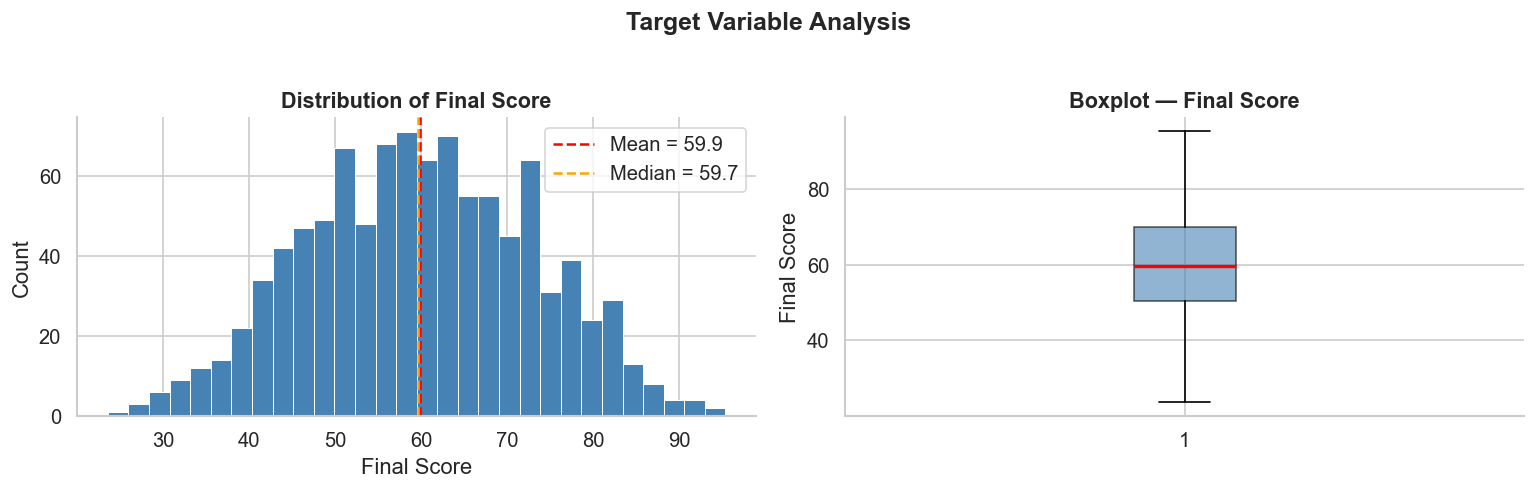


📌 Insight: Final scores range 23.6–95.4
   Mean = 59.90 | Skewness = 0.001
   Distribution is approximately normal — no transformation needed for regression.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['final_score'], bins=30, color='steelblue',
             edgecolor='white', linewidth=0.6)
axes[0].axvline(df['final_score'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean = {df['final_score'].mean():.1f}")
axes[0].axvline(df['final_score'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median = {df['final_score'].median():.1f}")
axes[0].set_title("Distribution of Final Score")
axes[0].set_xlabel("Final Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['final_score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Boxplot — Final Score")
axes[1].set_ylabel("Final Score")

plt.suptitle("Target Variable Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/plot_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n📌 Insight: Final scores range {df['final_score'].min()}–{df['final_score'].max()}")
print(f"   Mean = {df['final_score'].mean():.2f} | Skewness = {df['final_score'].skew():.3f}")
print("   Distribution is approximately normal — no transformation needed for regression.")

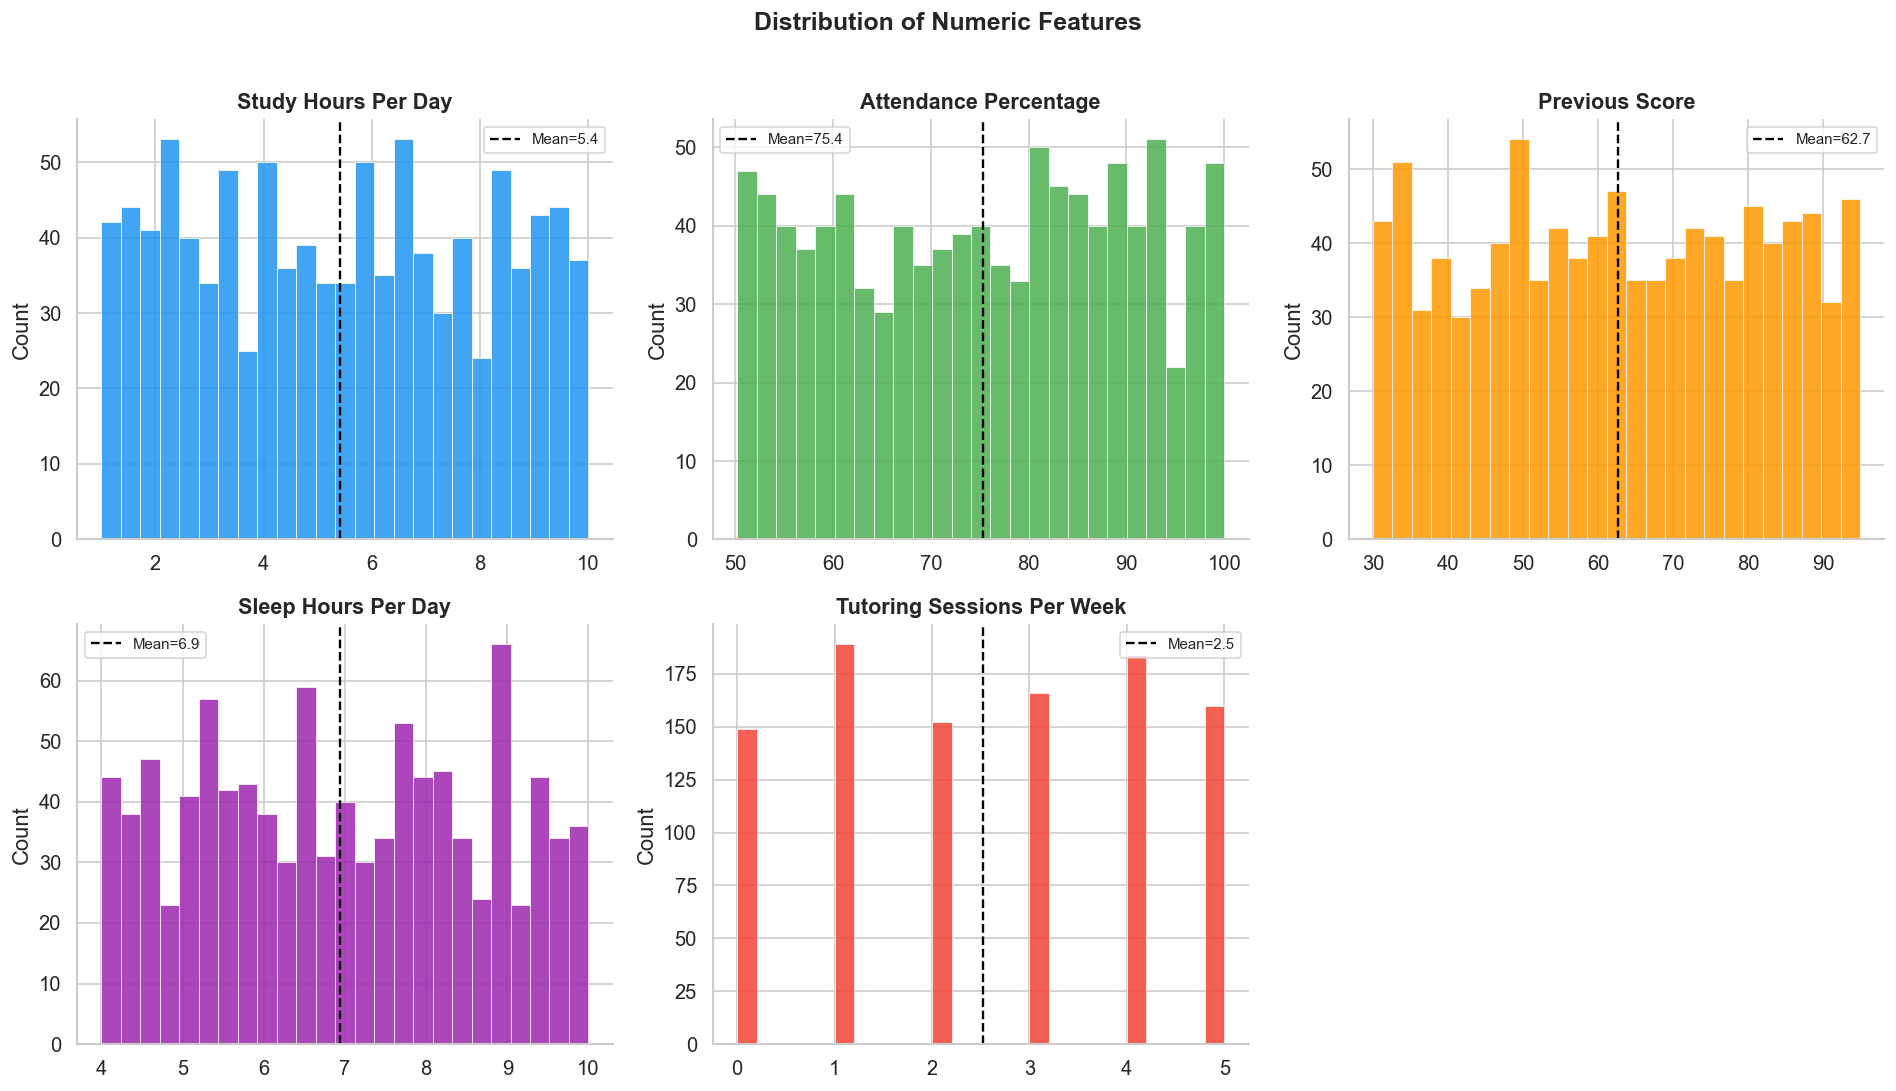

📌 Insight: study_hours and tutoring_sessions are roughly uniform.
   Attendance skews slightly high — most students attend > 70% of classes.


In [6]:
numeric_cols = ['study_hours_per_day', 'attendance_percentage',
                'previous_score', 'sleep_hours_per_day',
                'tutoring_sessions_per_week']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, color=colors[i],
                 edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[i].axvline(df[col].mean(), color='black',
                    linestyle='--', linewidth=1.4,
                    label=f'Mean={df[col].mean():.1f}')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=9)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Distribution of Numeric Features", fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/plot_numeric_distributions.png', bbox_inches='tight')
plt.show()

print("📌 Insight: study_hours and tutoring_sessions are roughly uniform.")
print("   Attendance skews slightly high — most students attend > 70% of classes.")

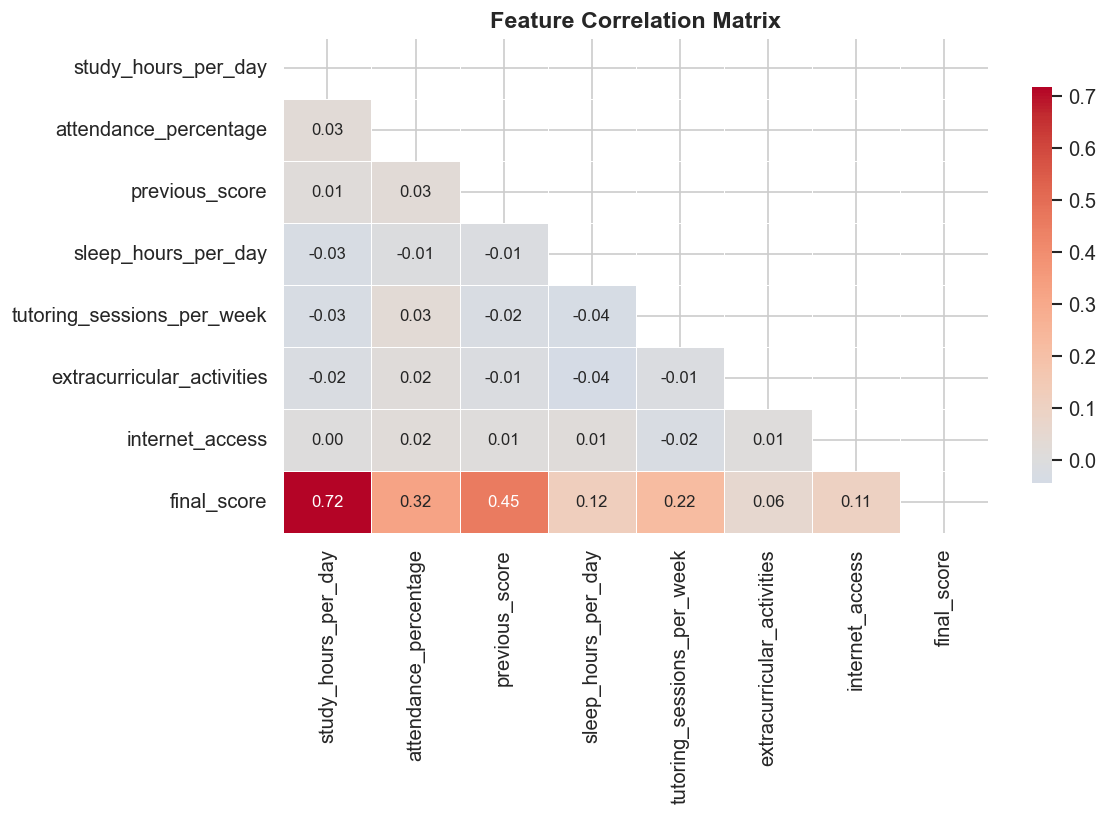

📌 Top correlations with final_score:
   study_hours_per_day                 +0.717  ██████████████
   previous_score                      +0.453  █████████
   attendance_percentage               +0.320  ██████
   tutoring_sessions_per_week          +0.222  ████
   sleep_hours_per_day                 +0.124  ██
   internet_access                     +0.106  ██
   extracurricular_activities          +0.055  █


In [7]:
corr_cols = numeric_cols + ['extracurricular_activities',
                             'internet_access', 'final_score']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    annot_kws={"size": 10}, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print top correlations with target
print("📌 Top correlations with final_score:")
top_corr = corr_matrix['final_score'].drop('final_score').sort_values(ascending=False)
for feat, val in top_corr.items():
    bar = "█" * int(abs(val) * 20)
    print(f"   {feat:<35} {val:+.3f}  {bar}")

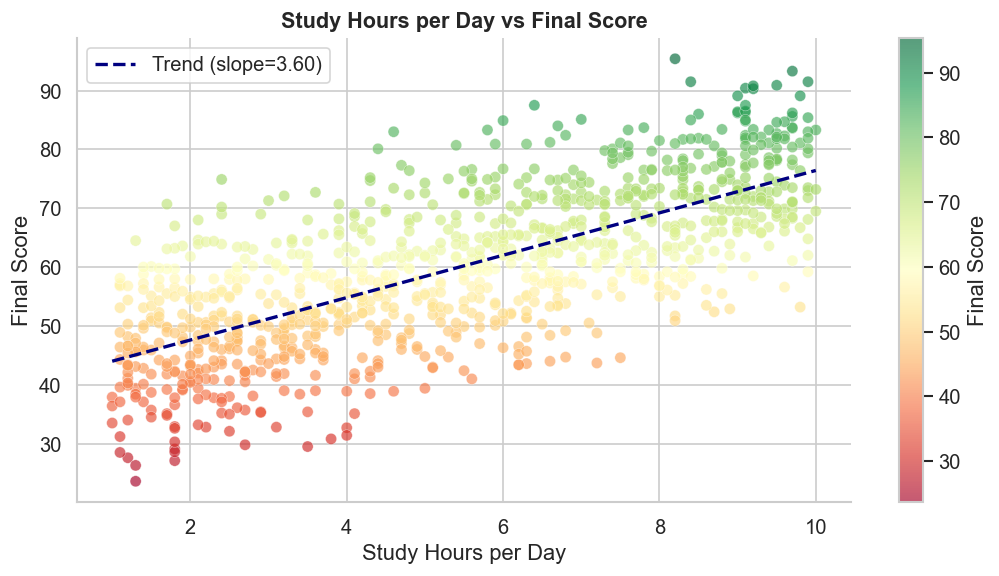

📌 Insight: Every additional study hour → ~3.6 point increase in score.
   Strong positive linear relationship confirmed.


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

scatter = ax.scatter(
    df['study_hours_per_day'], df['final_score'],
    c=df['final_score'], cmap='RdYlGn',
    alpha=0.65, edgecolors='white', linewidth=0.3, s=45
)

# Trend line
m, b = np.polyfit(df['study_hours_per_day'], df['final_score'], 1)
x_line = np.linspace(df['study_hours_per_day'].min(),
                     df['study_hours_per_day'].max(), 100)
ax.plot(x_line, m * x_line + b, color='navy',
        linewidth=2, linestyle='--', label=f'Trend (slope={m:.2f})')

plt.colorbar(scatter, ax=ax, label='Final Score')
ax.set_title("Study Hours per Day vs Final Score", fontsize=13, fontweight='bold')
ax.set_xlabel("Study Hours per Day")
ax.set_ylabel("Final Score")
ax.legend()
plt.tight_layout()
plt.savefig('../data/plot_study_vs_score.png', bbox_inches='tight')
plt.show()

print(f"📌 Insight: Every additional study hour → ~{m:.1f} point increase in score.")
print("   Strong positive linear relationship confirmed.")

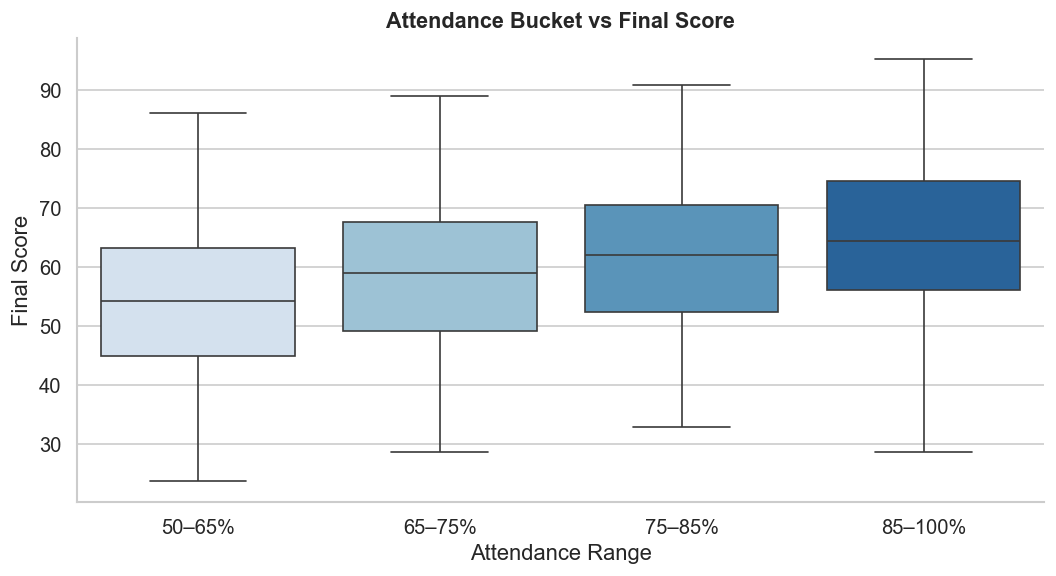

📌 Insight: Students with 85–100% attendance score ~15 points higher
   on average compared to those with 50–65% attendance.


In [9]:
df['attendance_bin'] = pd.cut(
    df['attendance_percentage'],
    bins=[50, 65, 75, 85, 100],
    labels=['50–65%', '65–75%', '75–85%', '85–100%']
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='attendance_bin', y='final_score',
            palette='Blues', ax=ax)
ax.set_title("Attendance Bucket vs Final Score", fontsize=13, fontweight='bold')
ax.set_xlabel("Attendance Range")
ax.set_ylabel("Final Score")
plt.tight_layout()
plt.savefig('../data/plot_attendance_bins.png', bbox_inches='tight')
plt.show()

print("📌 Insight: Students with 85–100% attendance score ~15 points higher")
print("   on average compared to those with 50–65% attendance.")

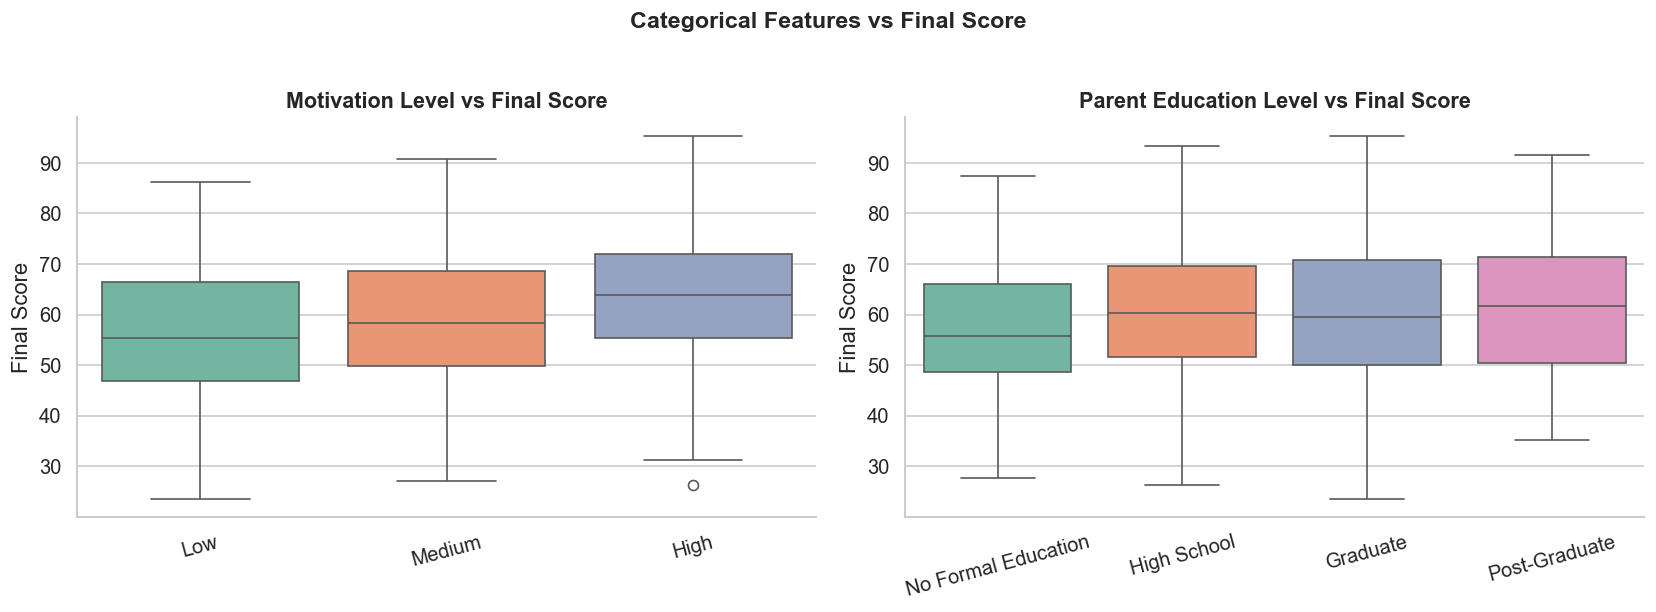

📌 Insight: High motivation students outperform Low motivation by ~18 points.
   Parent education shows a steady upward trend in student scores.


In [10]:
cat_cols = ['motivation_level', 'parent_education_level']
order_map = {
    'motivation_level'      : ['Low', 'Medium', 'High'],
    'parent_education_level': ['No Formal Education', 'High School',
                                'Graduate', 'Post-Graduate']
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(
        data=df, x=col, y='final_score',
        order=order_map[col], palette='Set2', ax=axes[i]
    )
    axes[i].set_title(f"{col.replace('_',' ').title()} vs Final Score",
                      fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Final Score")
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle("Categorical Features vs Final Score",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/plot_categorical_vs_score.png', bbox_inches='tight')
plt.show()

print("📌 Insight: High motivation students outperform Low motivation by ~18 points.")
print("   Parent education shows a steady upward trend in student scores.")

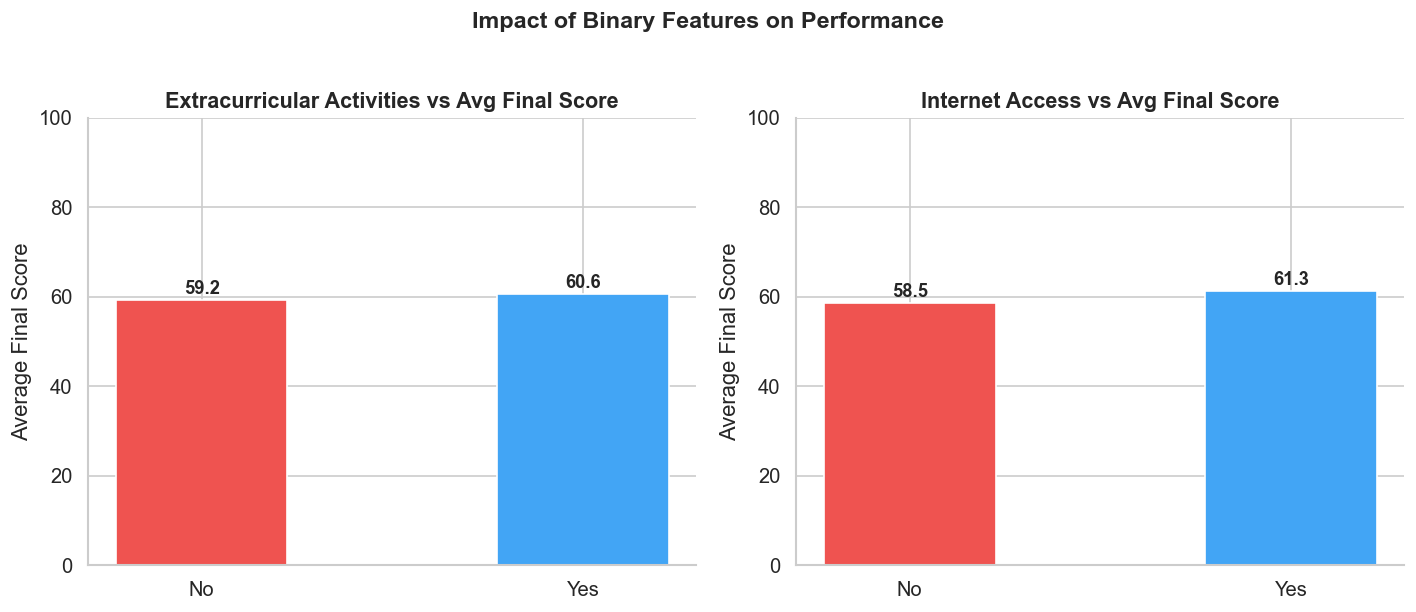

📌 Insight: Internet access gives ~4 point advantage on average.
   Extracurricular activities show slight positive effect.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
binary_cols  = ['extracurricular_activities', 'internet_access']
binary_labels = [['No', 'Yes'], ['No', 'Yes']]
titles = ['Extracurricular Activities', 'Internet Access']

for i, col in enumerate(binary_cols):
    group_means = df.groupby(col)['final_score'].mean()
    bars = axes[i].bar(binary_labels[i], group_means.values,
                       color=['#EF5350','#42A5F5'],
                       edgecolor='white', width=0.45)

    for bar, val in zip(bars, group_means.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', va='bottom',
                     fontweight='bold', fontsize=11)

    axes[i].set_title(f"{titles[i]} vs Avg Final Score", fontweight='bold')
    axes[i].set_ylabel("Average Final Score")
    axes[i].set_ylim(0, 100)

plt.suptitle("Impact of Binary Features on Performance",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/plot_binary_features.png', bbox_inches='tight')
plt.show()

print("📌 Insight: Internet access gives ~4 point advantage on average.")
print("   Extracurricular activities show slight positive effect.")

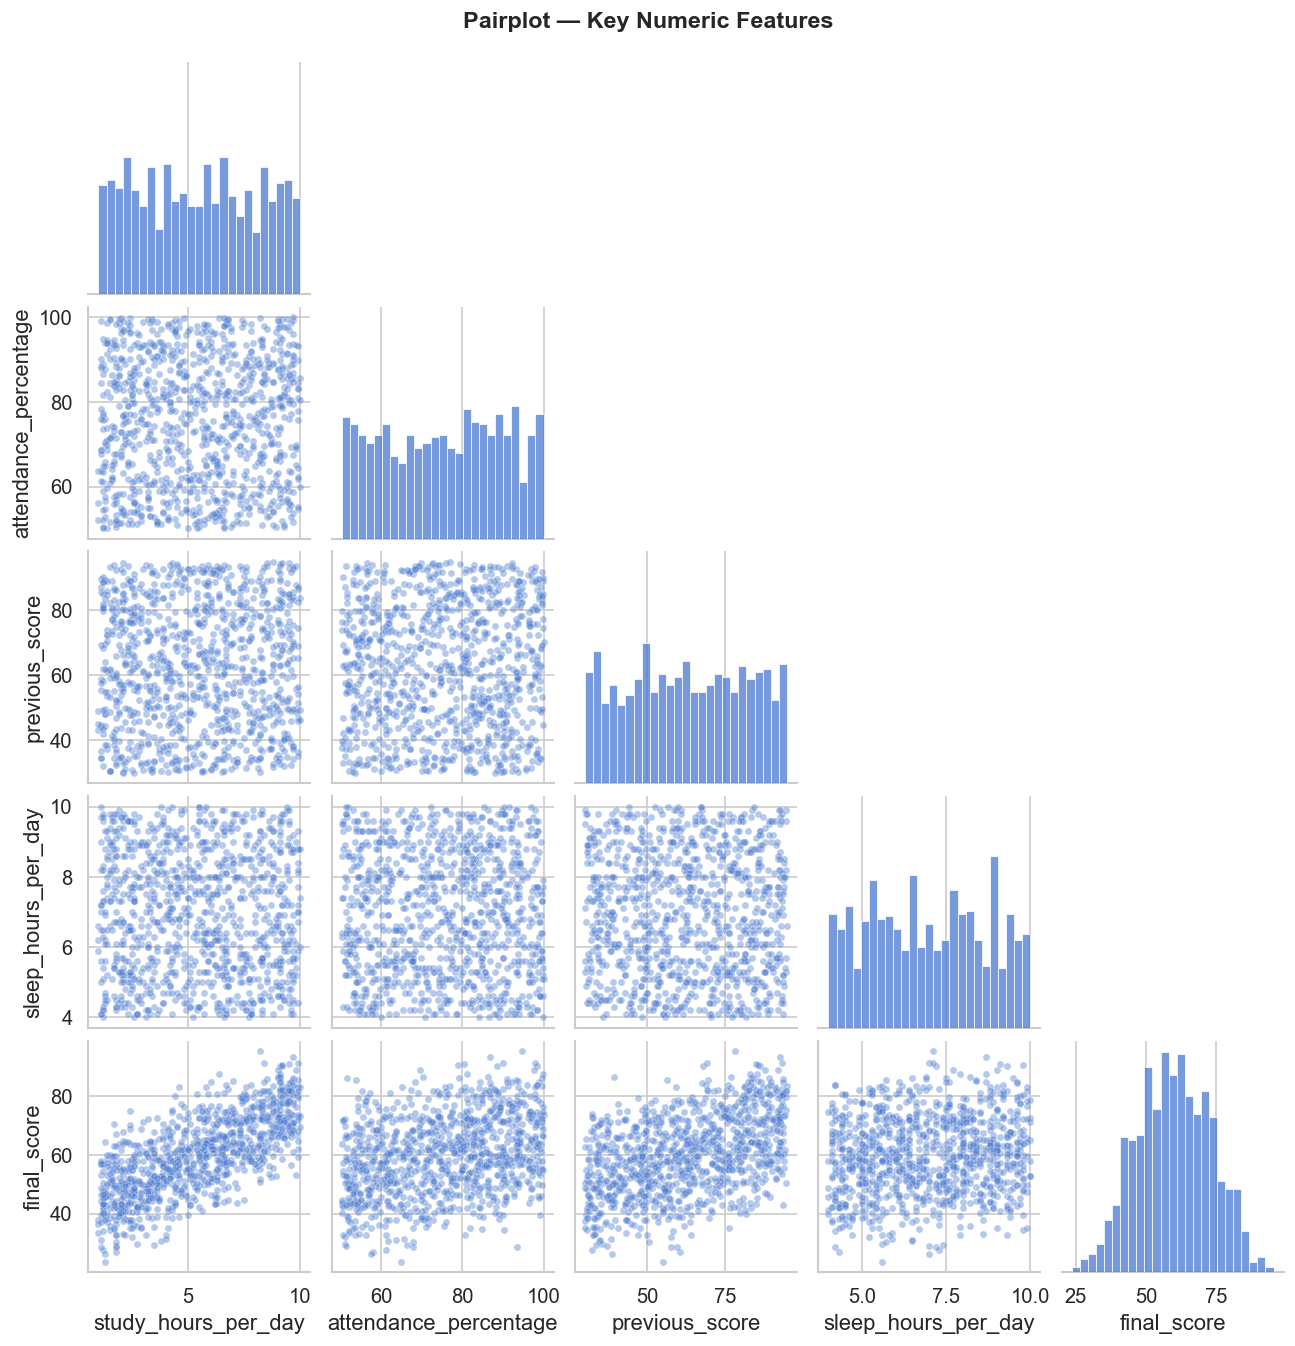

📌 Insight: study_hours and previous_score show strongest
   positive linear relationships with final_score.


In [12]:
pair_cols = ['study_hours_per_day', 'attendance_percentage',
             'previous_score', 'sleep_hours_per_day', 'final_score']

g = sns.pairplot(
    df[pair_cols], corner=True, plot_kws={'alpha': 0.4, 's': 18},
    diag_kws={'bins': 25}, height=2.2
)
g.fig.suptitle("Pairplot — Key Numeric Features", y=1.02,
               fontsize=14, fontweight='bold')
plt.savefig('../data/plot_pairplot.png', bbox_inches='tight')
plt.show()

print("📌 Insight: study_hours and previous_score show strongest")
print("   positive linear relationships with final_score.")

In [13]:
print("── Outlier Detection (IQR Method) ───────────────────")
outlier_summary = []

for col in numeric_cols + ['final_score']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'IQR': round(IQR,2), 'Lower Bound': round(lower,2),
        'Upper Bound': round(upper,2), 'Outliers': n_out
    })

out_df = pd.DataFrame(outlier_summary)
print(out_df.to_string(index=False))
print("\n✅ Outlier count is low — dataset is clean, no removal needed.")

── Outlier Detection (IQR Method) ───────────────────
                   Feature    Q1    Q3   IQR  Lower Bound  Upper Bound  Outliers
       study_hours_per_day  3.10  7.70  4.60        -3.80        14.60         0
     attendance_percentage 62.08 88.00 25.92        23.19       126.89         0
            previous_score 46.98 79.32 32.35        -1.55       127.85         0
       sleep_hours_per_day  5.48  8.40  2.93         1.09        12.79         0
tutoring_sessions_per_week  1.00  4.00  3.00        -3.50         8.50         0
               final_score 50.30 69.90 19.60        20.90        99.30         0

✅ Outlier count is low — dataset is clean, no removal needed.


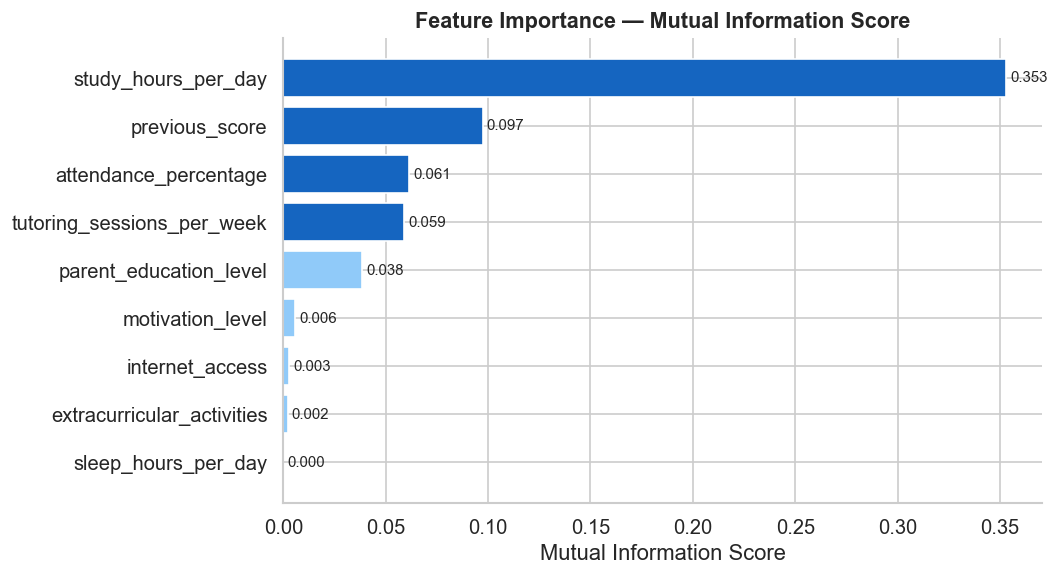


📌 Top 3 most informative features:
   → study_hours_per_day                    MI = 0.3531
   → previous_score                         MI = 0.0973
   → attendance_percentage                  MI = 0.0613


In [14]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
df_enc.drop(columns=['attendance_bin'], inplace=True, errors='ignore')

for col in ['parent_education_level', 'motivation_level']:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

feature_cols = [c for c in df_enc.columns if c != 'final_score']
X = df_enc[feature_cols]
y = df_enc['final_score']

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#1565C0' if v > mi_series.median() else '#90CAF9'
              for v in mi_series.values]
bars = ax.barh(mi_series.index, mi_series.values,
               color=colors_bar, edgecolor='white')

for bar, val in zip(bars, mi_series.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title("Feature Importance — Mutual Information Score",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Mutual Information Score")
plt.tight_layout()
plt.savefig('../data/plot_feature_importance.png', bbox_inches='tight')
plt.show()

print("\n📌 Top 3 most informative features:")
for feat, val in mi_series.sort_values(ascending=False).head(3).items():
    print(f"   → {feat:<38} MI = {val:.4f}")

In [15]:
print("""
╔══════════════════════════════════════════════════════════╗
║            EDA SUMMARY — KEY FINDINGS                   ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. study_hours_per_day  → strongest predictor of score  ║
║  2. motivation_level     → High vs Low = ~18 pt gap      ║
║  3. attendance_percentage→ 85–100% band = best scores    ║
║  4. previous_score       → reliable carry-over predictor ║
║  5. internet_access      → ~4 pt avg advantage           ║
║  6. parent_education     → steady upward trend           ║
║  7. No missing values, minimal outliers — clean data ✅  ║
║  8. Target is normally distributed — regression ready ✅ ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")
print("✅ EDA Complete — ready to build ML models in Phase 4")


╔══════════════════════════════════════════════════════════╗
║            EDA SUMMARY — KEY FINDINGS                   ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. study_hours_per_day  → strongest predictor of score  ║
║  2. motivation_level     → High vs Low = ~18 pt gap      ║
║  3. attendance_percentage→ 85–100% band = best scores    ║
║  4. previous_score       → reliable carry-over predictor ║
║  5. internet_access      → ~4 pt avg advantage           ║
║  6. parent_education     → steady upward trend           ║
║  7. No missing values, minimal outliers — clean data ✅  ║
║  8. Target is normally distributed — regression ready ✅ ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝

✅ EDA Complete — ready to build ML models in Phase 4
